# Feature sifting on a clean-or-noise problem

**Problem.** `phd/jax_core/tasks/clean_or_noise_sifting.py`, a variant of
`phd/jax_core/tasks/feature_sifting.py` that changes exactly one thing: what a drawn candidate
feature *is*. The target is a sum of 10 true signals, each uniform on $[-1, 1]$, with weights in
$\{-1, +1\}$ and $N(0, 1)$ observation noise, so MSE is 1.0 for an optimal predictor and
$1 + 10/3 = 4.33$ for the mean predictor. The learner observes 20 candidate slots, and every
slot was drawn as either an **exact, uncorrupted copy** of one of the 10 signals (with
probability `CLEAN_PROB` = 5%) or an **independent uniform draw over the same range** (95%).
Nothing sits in between.

The original sifting task mixes every candidate with pure noise through its own coefficient
drawn uniformly from $[0, 1]$, so its pool is a *continuum* of partial views and a method can
make steady progress by trading a noisier feature for a slightly cleaner one. Here quality is
binary: there is no gradient of feature quality to climb, and the two kinds of candidate have
the *same* marginal distribution — same range, same variance — so a slot cannot be judged from
its own values at all. The only handle is the association with the target, which takes holding a
candidate long enough for its weight to move. Because a copy is exact, a learner that covers all
10 signals reaches 1.0 **exactly**, so what the MSE measures is the search.

**Both sampling rules are run**, and they turn out to pose quite different problems. *Without
replacement* (the task's default) a clean candidate takes a signal no other slot is currently
holding, so the learner never accumulates two copies of the same one and every clean slot it
gains is a signal newly covered; at most 10 of the 20 slots can be clean at once, and a draw that
finds every signal already taken comes out as noise instead. *With replacement* — the original
task's independent draws — duplicates are possible: harmless to the prediction, since the weight
simply splits between them, but a wasted slot that a dead-weight test has no reason to cut.
Either way a signal can go uncovered for a long time: with 20 slots at a 5% hit rate the pool
holds one real signal on average at the start, and a method that never prunes is stuck with
whatever it was dealt.

The two are run over the same seeds, so a given seed is the same teacher under both rules and the
figures may be read as a paired comparison.

**Learner.** A single linear predictor over the 20 slots, plus a bias, every weight starting at
zero. There is no wiring to discover here as there is in the multi-linear version of this
notebook — a slot is always connected and always carries a value — so the padded weight matrix
is one row and the only structural decision is which slots to throw away. Pruning a slot does
not free a weight, it **redraws the feature behind it**, and the learner resets that slot to its
starting state (zero weight, `INIT_LR`, no traces) so the new candidate arrives with no
inherited history. The learner therefore always has 20 weights doing work; what changes under
them is what they are looking at.

**Runs.** LMS at a fixed step-size, Autostep, Autostep + generate & test (which cuts a slot the
step its weight crosses zero), that plus a subgradient L1 penalty, and Autostep + band (which
cuts a slot whose weight is inside the noise band of a dead slot of the same age). The first two
never prune, and show what the initial random pool is worth.

**Why the L1 variant is here.** The bare zero-crossing test is not scale-free in the way it
looks. A dead slot's weight is a random walk plus a pull toward zero, and while the pull's
*strength* and the walk's *variance* both scale with the step-size $\alpha$ — leaving the
stationary distribution zero-mean with standard deviation $\sigma_\delta\sqrt{\alpha/2}$, and so
scale-free — the *rate* of the pull is $\alpha\,\mathbb{E}[x^2]$, giving a relaxation time of
$1/(\alpha\,\mathbb{E}[x^2])$ steps that does **not** cancel. Run for less than that and the pull
is never felt: the weight is a driftless walk, whose first-return times to zero are heavy-tailed
($P(T > t)\sim t^{-1/2}$, infinite mean), so a persistent fraction of dead slots never cross zero
again and are never tested. That matters more here than in a continuum pool, because a frozen
mistake is a slot wasted on a feature carrying *no* information at all.

L1 fixes that without touching `INIT_LR`. Its subgradient contributes a *constant-magnitude*
drift $\alpha\lambda$ against gradient noise $\alpha\sigma$, so the drift-to-noise ratio
$\lambda/\sigma$ is $\alpha$-free, and the time to be pulled back across zero from a diffusive
excursion $|w|\sim\alpha\sigma\sqrt{N\,\mathbb{E}[x^2]}$ is
$\sigma\sqrt{N\,\mathbb{E}[x^2]}/\lambda$ — with $\alpha$ cancelling outright. A dead weight is
*driven* back to zero rather than left to relax there, at any step-size.

**Why the band variant is here.** L1 fixes the stall by *driving* a dead weight back to zero; the
band variant fixes it by not waiting for zero at all. A dead slot's weight is a random walk whose
one-sigma envelope is $s = \sqrt{\alpha\,\mathbb{E}[\delta^2]/2}$ (derived in
`phd/sandbox/feature_sifting/exploration/lasso_step_size_protection_algo.ipynb`), so
"indistinguishable from dead" is testable outright, every step, with no crossing needing to happen.
The catch is that a newborn slot sits at $w = 0$ — the deepest point inside that envelope — and at
`INIT_LR` even a genuinely useful weight needs many steps to climb out, so the *stationary* band
cuts every candidate on arrival and the pool never settles. Judging the weight against the band
for its own **age**, $s(t) = s\sqrt{1 - \rho^t}$ with $\rho = \mathbb{E}[(1 - \alpha x^2)^2]$,
removes that: the band opens from zero at exactly the rate a dead weight wanders, while a useful
weight's mean grows linearly and overtakes it after
$\approx 9\,\mathbb{E}[\delta^2] / (w^{*2}\,\mathbb{E}[x^2])$ steps — a step count in which
$\alpha$ cancels outright, so it holds at any step-size. The rule as run here cuts at **twice**
that width; the closing note says what that factor buys. Here $w^* = 1$ and
$\mathbb{E}[x^2] = 1/3$, so a real signal announces itself within a few hundred steps however
small `INIT_LR` is. That is the same $\alpha$-freedom L1 buys, taken from the test instead of
from a penalty on the loss.

In [10]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns

from phd.jax_core.optimizers.idbd import optax_idbd, IDBDState
from phd.jax_core.tasks.clean_or_noise_sifting import CleanOrNoiseSiftingTask
from phd.jax_core.utils import stack_pytrees, tree_replace
from phd.research_utils.analysis.analysis_utils import get_color_palette

sns.set_theme('notebook', 'white')
%matplotlib inline

In [11]:
# --- Problem ---
N_TARGET_FEATURES = 10               # true signals the target function sums
N_LEARNER_FEATURES = 10              # candidate slots the learner observes
CLEAN_PROB = 0.01                    # chance a drawn candidate is an exact copy of a signal
SAMPLING = {False: 'without replacement'}#,   # both rules are run, and plotted separately
            #True: 'with replacement'}
NOISE_STD = 1.0                      # observation noise on the target
INPUT_BOUNDS = (-1.0, 1.0)           # uniform range, shared by the signals and the distractors

# --- Optimizers ---
LMS_LR = 0.001
INIT_LR = 1e-10                      # Autostep's starting step-size for every slot
META_LR = 0.02
L1_COEFF = 0.01                      # subgradient L1 on the candidate weights (method 4)
BAND_TRACE_HORIZON = 1_000           # EMA horizon for E[delta^2] (method 5)

# --- Training and recording ---
NUM_STEPS = 200_000
N_SEEDS = 30                         # vmapped into one scan; scan width is nearly free
N_SNAPSHOTS = 200                    # recording points per run
BASE_SEED = 0

# --- Derived ---
N_OUTPUTS = 1                        # one target, but the (output, slot) grid shape is kept
N_SLOTS = N_LEARNER_FEATURES + 1     # one weight per candidate, plus a bias column
INPUT_VAR = (INPUT_BOUNDS[1] - INPUT_BOUNDS[0]) ** 2 / 12   # variance of any one feature
IRREDUCIBLE_MSE = NOISE_STD ** 2                            # MSE with every signal covered
BASELINE_MSE = IRREDUCIBLE_MSE + N_TARGET_FEATURES * INPUT_VAR   # the mean predictor: none covered
BLOCK_LEN = NUM_STEPS // N_SNAPSHOTS


def max_clean(with_replacement):
    """Most slots that can hold a real signal at once under the given sampling rule.

    Without replacement the signals are handed out one to a slot, so the pool cannot hold more
    clean slots than the target function has signals, however many slots the learner has.
    """
    if with_replacement:
        return N_LEARNER_FEATURES
    return min(N_LEARNER_FEATURES, N_TARGET_FEATURES)

## Learners

Each method is a self-contained `eqx.Module` with `init()` and `step(inputs, y)`, and carries the
`prune_mask` the task reads to redraw candidates. `inputs` is the `(n_outputs, n_learner_features)`
slot grid, padded here with the bias column; the weight matrix covers the whole grid. Keeping the
`n_outputs` axis around with a single output costs nothing and keeps the code identical to the
multi-output version of this notebook.

In [12]:
def slot_inputs(inputs):
    """Pad the slot grid with the bias column: a constant-1 input, never a candidate.

    Keeping the bias inside the weight matrix is what Autostep's per-output-row normalizer
    needs — it does not support a separate bias vector.
    """
    return jnp.concatenate([inputs, jnp.ones((N_OUTPUTS, 1))], axis=1)


def linear_loss_and_grads(w, x, y):
    """Squared error, and the LMS gradient `delta * x`.

    That is the exact gradient up to the constant factor 2, which is folded into the step-size.
    """
    error = jnp.sum(w * x, axis=-1) - y
    return jnp.sum(error ** 2), error[:, None] * x


def reset_pruned(w, opt_state, prune_mask):
    """Return every slot the learner just cut to its starting state: zero weight, `INIT_LR`, no traces.

    In the multi-linear version of this notebook a replacement lands in a *different* grid
    position, one already parked at these values, so nothing had to be reset explicitly. Here the
    slot index never changes — only the feature behind it does — so this reset is what makes a
    fresh candidate start with no inherited history. It is applied on the step the slot is cut,
    and the task swaps the new candidate in at the top of the next one.
    """
    pruned = jnp.pad(prune_mask, ((0, 0), (0, 1)))     # the bias column is never pruned
    return jnp.where(pruned, 0.0, w), IDBDState(
        init_beta=opt_state.init_beta,
        beta=jnp.where(pruned, opt_state.init_beta, opt_state.beta),
        h=jnp.where(pruned, 0.0, opt_state.h),
        v=jnp.where(pruned, 0.0, opt_state.v),
    )

In [13]:
class LMS(eqx.Module):
    """Least mean squares at a fixed step-size on the initial pool; never prunes."""
    w: jax.Array
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        return cls(w=jnp.zeros((N_OUTPUTS, N_SLOTS)),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_LEARNER_FEATURES), dtype=bool))

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        return tree_replace(self, w=self.w - LMS_LR * grads), loss   # prune_mask stays all-False

In [14]:
class Autostep(eqx.Module):
    """Autostep (IDBD) on the initial pool: a step-size per slot, but no pruning."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer = optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True)
        w = jnp.zeros((N_OUTPUTS, N_SLOTS))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_LEARNER_FEATURES), dtype=bool))

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        # Autostep consumes the loss gradient and the prediction gradient (= x, this being a
        # linear model), and normalizes each output's row of step-sizes on its own.
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        return tree_replace(self, w=self.w + updates, opt_state=opt_state), loss

In [15]:
class AutostepGT(eqx.Module):
    """Autostep + generate & test: a slot is cut the step its weight crosses zero.

    The task redraws every cut slot, so the learner keeps the same 20 weights and trades away the
    ones a real gradient is no longer holding off zero — for a replacement that is an exact copy
    of a true signal only `CLEAN_PROB` of the time, and pure noise otherwise. A cut slot is reset
    to `w = 0` (`reset_pruned`), so the product below is zero on the new candidate's first step
    and it is never cut on arrival.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer = optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True)
        w = jnp.zeros((N_OUTPUTS, N_SLOTS))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_LEARNER_FEATURES), dtype=bool))

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w = self.w + updates

        # The bias column is not a candidate, so it is sliced back off the mask.
        prune_mask = (self.w * w < 0.0)[:, :N_LEARNER_FEATURES]
        w, opt_state = reset_pruned(w, opt_state, prune_mask)
        return tree_replace(self, w=w, opt_state=opt_state, prune_mask=prune_mask), loss

In [16]:
class AutostepL1GT(eqx.Module):
    """Autostep + L1 + G&T: the same zero-crossing cut, plus a subgradient L1 penalty.

    `lambda * sign(w)` joins the loss gradient, so it drives the weight update *and* Autostep's
    step-size adaptation. Its contribution to a step is `alpha * lambda` against gradient noise
    `alpha * sigma`, so the ratio is step-size free: a dead weight is actively driven back across
    zero instead of waiting on a mean-reversion whose rate vanishes with `alpha`. That is what
    makes the cut keep firing at any `INIT_LR`, which the bare test does not.

    The bias against a true weight of magnitude 1 is `L1_COEFF / E[x^2]` = 0.03, so the penalty
    costs the fit little while doing its work on the dead slots.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    l1: float = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer = optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True)
        w = jnp.zeros((N_OUTPUTS, N_SLOTS))
        return cls(optimizer=optimizer, l1=L1_COEFF, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_LEARNER_FEATURES), dtype=bool))

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        # L1 on the candidates only: shrinking the bias fights the target's mean, not structure.
        # `loss` stays pure squared error, so the MSE curves remain comparable across methods.
        grads = grads + self.l1 * jnp.sign(self.w).at[:, -1].set(0.0)
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w = self.w + updates

        prune_mask = (self.w * w < 0.0)[:, :N_LEARNER_FEATURES]
        w, opt_state = reset_pruned(w, opt_state, prune_mask)
        return tree_replace(self, w=w, opt_state=opt_state, prune_mask=prune_mask), loss

In [17]:
class AutostepBand(eqx.Module):
    """Autostep + band pruning: a slot is cut once its weight is inside the noise band of a dead
    slot **of the same age**.

    A dead slot's weight is a mean-reverting random walk whose stationary rms is the one-sigma
    band `s = sqrt(alpha * E[delta^2] / 2)` (derived in
    `phd/sandbox/feature_sifting/exploration/lasso_step_size_protection_algo.ipynb`), with
    `E[delta^2]` the *plain* squared residual of the output and `alpha` the step-size that
    multiplies the half-MSE gradient, which is exactly what this notebook hands the optimizer.
    `E[x^2]` cancels out of `s`, so a feature's scale does not enter — which matters here, where
    a distractor is drawn from the same range as a real signal and so has the same scale anyway.

    The **stationary** band is useless on its own: every new candidate is born at `w = 0`, deep
    inside it, and at `INIT_LR` a *useful* weight needs many steps to climb out, so the test kills
    every candidate on arrival and the pool never settles. What the rule needs is the band for a
    weight of the slot's own age,

        s(t) = s * sqrt(m_t),    m_t = 1 - rho^t,    rho = E[(1 - alpha x^2)^2]

    which starts at zero alongside the weight and widens at exactly the rate a dead weight
    wanders. The age is accumulated per step from the realized `x`, so it keeps meaning the right
    thing while Autostep is still ramping `alpha` up from `INIT_LR`.

    That accumulation is kept as `log(1 - m_t)` rather than as `m_t` itself, because the direct
    form `m <- 1 - (1 - alpha x^2)^2 (1 - m)` cancels catastrophically in float32: once
    `alpha E[x^2]` drops below `eps / 2 ~ 6e-8`, `1 - alpha x^2` rounds to exactly 1 and the
    update becomes `m <- m`, freezing the trace at zero. A zero maturity is a zero-width band, so
    nothing is ever prunable — and it is permanent rather than transient, since Autostep drives a
    *dead* slot's `alpha` down and away from that threshold, never up through it. At
    `INIT_LR = 1e-6` the direct form is within a factor of two of breaking; at `1e-12` it cuts
    nothing at all and the method silently degenerates to plain Autostep. Accumulating
    `2 log1p(-alpha x^2)` instead is accurate down to ~1e-13 and makes the method behave
    identically across those six orders of magnitude.

    This is what makes the test scale-free where the bare zero-crossing test is not. A useful
    weight's mean clears its own aged band after roughly `9 E[delta^2] / (w*^2 E[x^2])` steps —
    the `alpha` in the band and the `alpha` in the weight's growth rate cancel outright — so no
    L1 is needed to keep the rule firing at small `INIT_LR`. With `w* = 1` and `E[x^2] = 1/3`
    that is a few hundred steps at the start of a run and under a hundred once the residual has
    come down.

    The width used below is **two** sigma, not the one sigma derived here. That factor is what
    lets the rule cut a *split* weight: two slots holding copies of one signal (possible only
    under `with_replacement=True`) carry about half its weight each, which a one-sigma band never
    reaches, so at one sigma the method stalls on duplicates exactly where bare G&T does.

    The weight is tested against the maturity it had *before* this step's update, so a candidate
    on its first step meets a zero-width band and always survives it.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    v: jax.Array          # (n_outputs, 1) EMA of the output's squared residual
    v_weight: jax.Array   # accumulated EMA gain, so `v` reads unbiased from step 1
    log_imm: jax.Array    # (n_outputs, n_slots) log(1 - maturity): 0 at birth, -inf once mature
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer = optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True)
        w = jnp.zeros((N_OUTPUTS, N_SLOTS))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   v=jnp.zeros((N_OUTPUTS, 1)), v_weight=jnp.zeros(()),
                   log_imm=jnp.zeros_like(w),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_LEARNER_FEATURES), dtype=bool))

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        # `linear_loss_and_grads` reduces the squared error over outputs; the band needs the
        # residual itself, so the two lines are spelled out here instead.
        error = jnp.sum(self.w * x, axis=-1) - y
        loss, grads = jnp.sum(error ** 2), error[:, None] * x
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w = self.w + updates

        # E[delta^2] belongs to the output's residual, not to any one slot, so a redraw leaves it
        # alone; `v_weight` de-biases it away from its zero start.
        gain = 1.0 / BAND_TRACE_HORIZON
        v = self.v + gain * (error[:, None] ** 2 - self.v)
        v_weight = self.v_weight + gain * (1.0 - self.v_weight)

        # The band the *pre-update* weight age calls for, then the age advances.
        alpha = jnp.exp(opt_state.beta)
        band = jnp.sqrt(alpha * (v / v_weight) / 2.0 * -jnp.expm1(self.log_imm))
        log_imm = self.log_imm + 2.0 * jnp.log1p(-alpha * x ** 2)

        prune_mask = (jnp.abs(w) < band)[:, :N_LEARNER_FEATURES]
        w, opt_state = reset_pruned(w, opt_state, prune_mask)
        # A redrawn slot restarts its warm-up, so it meets a zero-width band on its first step.
        log_imm = jnp.where(jnp.pad(prune_mask, ((0, 0), (0, 1))), 0.0, log_imm)
        return tree_replace(self, w=w, opt_state=opt_state, v=v, v_weight=v_weight,
                            log_imm=log_imm, prune_mask=prune_mask), loss

## Training

In [18]:
def make_task(seed, with_replacement):
    return CleanOrNoiseSiftingTask(
        n_target_features=N_TARGET_FEATURES, n_learner_features=N_LEARNER_FEATURES,
        clean_prob=CLEAN_PROB, with_replacement=with_replacement,
        target_noise_std=NOISE_STD, input_bounds=INPUT_BOUNDS,
        key=jax.random.PRNGKey(seed))


def train(learner, task):
    """`NUM_STEPS` of online training, summarized into `N_SNAPSHOTS` equal blocks."""
    def one_step(carry, _):
        learner, task = carry
        # The task is single-output and speaks in flat slot vectors; the learner keeps the
        # (output, slot) grid shape, so the two meet with one row.
        task, (inputs, y) = task.step(learner.prune_mask[0])   # the task redraws what was cut
        learner, loss = learner.step(inputs[None, :], y)
        return (learner, task), (loss, jnp.sum(learner.prune_mask))

    def block(carry, _):
        carry, (losses, n_cut) = jax.lax.scan(one_step, carry, length=BLOCK_LEN)
        task = carry[1]
        return carry, (losses.mean(), n_cut.mean(),
                       jnp.mean(task.is_clean.astype(jnp.float32)),
                       task.n_covered.astype(jnp.float32))

    _, out = jax.lax.scan(block, (learner, task), length=N_SNAPSHOTS)
    return out


def run(make_learner, with_replacement):
    """Train `N_SEEDS` independent runs — a fresh teacher and pool each — in one vmapped scan."""
    tasks = stack_pytrees([make_task(BASE_SEED + s, with_replacement) for s in range(N_SEEDS)])
    keys = ('mse', 'cut_rate', 'clean', 'covered')
    out = jax.jit(jax.vmap(lambda task: train(make_learner(), task)))(tasks)
    return {'steps': np.arange(1, N_SNAPSHOTS + 1) * BLOCK_LEN,
            **{k: np.asarray(v) for k, v in zip(keys, out)}}


def run_all(with_replacement):
    """Every method on one sampling rule. `with_replacement` is static, so each rule compiles
    its own scan; the seeds are shared, so the two rules see the same teachers."""
    return {
        f'LMS (lr {LMS_LR:g})': run(LMS.init, with_replacement),
        'Autostep': run(Autostep.init, with_replacement),
        'Autostep + G&T': run(AutostepGT.init, with_replacement),
        f'Autostep + L1 {L1_COEFF:g} + G&T': run(AutostepL1GT.init, with_replacement),
        'Autostep + band': run(AutostepBand.init, with_replacement),
    }


runs = {with_replacement: run_all(with_replacement) for with_replacement in SAMPLING}

## Results

Each sampling rule gets its own pair of figures, on shared axes so the two can be read against
each other; the seeds are shared too, so a given seed is the same teacher under both rules.

Coverage is what caps a method: every signal it has no copy of leaves its own variance $1/3$ in
the residual. The dotted line beside each learning curve is that floor for the coverage the
method actually reached, so the gap between a solid curve and its own dotted one is what the
method's *weights* got wrong, separated from what its *search* never found.

The two pool panels are worth reading together. Without replacement they carry the same
information on two scales — no copy is ever redundant, so the number of clean slots and the
number of distinct signals covered are the same number. With replacement they come apart, and the
gap between them is exactly the slots lost to duplicates.

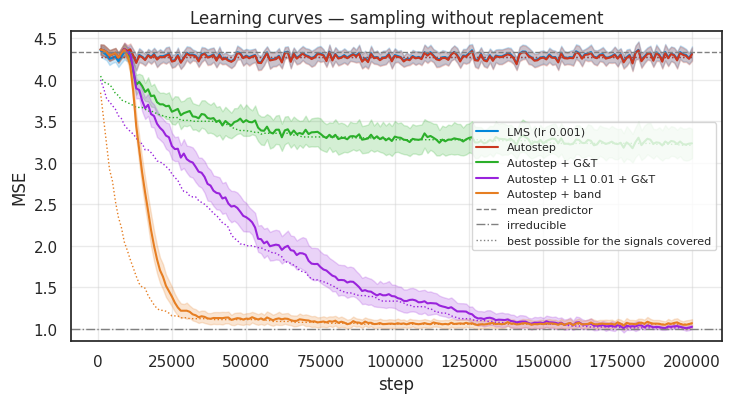

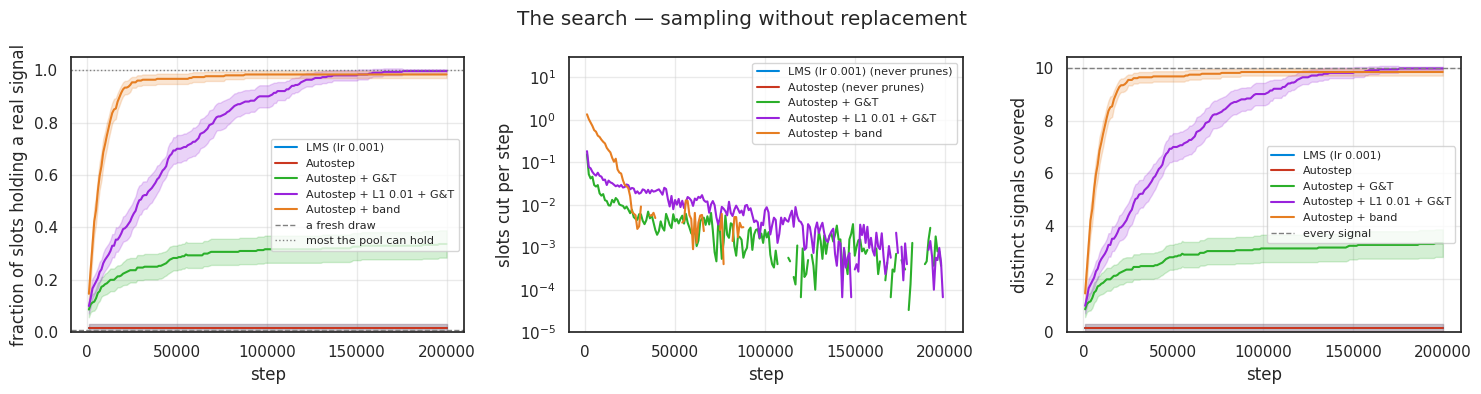

In [19]:
def plot_curves(methods, with_replacement):
    """MSE per method, mean +- 2 standard errors over seeds, against the floor set by the signals
    each method has actually covered (dotted, in the method's own color)."""
    plt.figure(figsize=(7.5, 4.2))
    for (label, res), color in zip(methods.items(), get_color_palette(n=len(methods))):
        mean = res['mse'].mean(0)
        sem = res['mse'].std(0) / np.sqrt(N_SEEDS)
        plt.plot(res['steps'], mean, color=color, label=label)
        plt.fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=color, alpha=0.2)
        # Every signal the method has no copy of leaves its own variance in the residual.
        floor = IRREDUCIBLE_MSE + (N_TARGET_FEATURES - res['covered']) * INPUT_VAR
        plt.plot(res['steps'], floor.mean(0), color=color, ls=':', lw=1)
    plt.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor')
    plt.axhline(IRREDUCIBLE_MSE, ls='-.', c='gray', lw=1, label='irreducible')
    plt.plot([], [], c='gray', ls=':', lw=1, label='best possible for the signals covered')
    plt.xlabel('step')
    plt.ylabel('MSE')
    # Both rules share the axes, so the two figures can be read against each other directly.
    plt.ylim(0.85, BASELINE_MSE + 0.25)
    plt.title(f'Learning curves — sampling {SAMPLING[with_replacement]}')
    plt.grid(alpha=0.4)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_search(methods, with_replacement):
    """What the sifting does: how much of the pool is real signal, how fast it churns, and how
    many distinct signals it has found a copy of."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for (label, res), color in zip(methods.items(), get_color_palette(n=len(methods))):
        for ax, key in ((axes[0], 'clean'), (axes[2], 'covered')):
            mean = res[key].mean(0)
            sem = res[key].std(0) / np.sqrt(N_SEEDS)
            ax.plot(res['steps'], mean, color=color, label=label)
            ax.fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=color, alpha=0.2)

        rate = res['cut_rate'].mean(0)
        if np.any(rate > 0):
            axes[1].plot(res['steps'], np.where(rate > 0, rate, np.nan), color=color, label=label)
        else:
            axes[1].plot([], [], color=color, label=f'{label} (never prunes)')

    axes[0].axhline(CLEAN_PROB, ls='--', c='gray', lw=1, label='a fresh draw')
    axes[0].axhline(max_clean(with_replacement) / N_LEARNER_FEATURES, ls=':', c='gray', lw=1,
                    label='most the pool can hold')
    axes[0].set_ylabel('fraction of slots holding a real signal')
    axes[0].set_ylim(0, 1.05)
    axes[1].set_ylabel('slots cut per step')
    axes[1].set_yscale('log')
    axes[1].set_ylim(1e-5, 30)
    axes[2].axhline(N_TARGET_FEATURES, ls='--', c='gray', lw=1, label='every signal')
    axes[2].set_ylabel('distinct signals covered')
    axes[2].set_ylim(0, N_TARGET_FEATURES + 0.4)
    for ax in axes:
        ax.set_xlabel('step')
        ax.grid(alpha=0.4)
        ax.legend(fontsize=8)
    fig.suptitle(f'The search — sampling {SAMPLING[with_replacement]}')
    fig.tight_layout()
    plt.show()


for with_replacement, methods in runs.items():
    plot_curves(methods, with_replacement)
    plot_search(methods, with_replacement)

**Without replacement, pruning is the whole game.** LMS and Autostep keep the pool they were
dealt — 5% clean, one signal covered — and sit just under the mean predictor for the whole run,
while all three pruning rules reach every signal and settle at the irreducible 1.0. The rule makes
success cheap and permanent: a clean draw is guaranteed to be a signal the learner does not
already have, and because no second slot can hold a copy of it, its weight lands on one slot at
full magnitude $\pm 1$ instead of splitting. A useful feature is therefore maximally visible to
any dead-weight test, and the learner only has to get lucky ten times.

What separates the methods there is the *cost*, in the middle panel, and it spans four orders of
magnitude for the same final answer:

- **Autostep + G&T** is the slowest to converge (~45k steps against ~20k) and its cut rate decays
  by more than two orders of magnitude — the same stall as on the multi-linear problem: with a
  small initial step-size a distractor's weight wanders as an almost driftless random walk for a
  long time before being pulled back across zero, because the strength of the pull scales with the
  weight magnitude while the walk does not. It converges anyway, because ten permanent successes
  are all it needs.
- **Autostep + L1 + G&T** holds a steady ~0.1 cuts per step forever; the penalty keeps pushing on
  weights the loss is indifferent to, so the test keeps firing.
- **Autostep + band** never stops: ~4 cuts per step for the whole run, each of the ten slots it
  cannot fill being redrawn every other step. Once every signal is spoken for a redraw is
  *guaranteed* to come back as noise, so the churn is pure waste — the band recognizes a dead
  weight within a few steps of its birth and has no notion of "there is nothing better left to
  find". It costs nothing in MSE here, since a churning slot's weight sits near zero either way,
  but it is the failure mode to watch wherever a redraw is expensive or a fresh feature needs time
  to prove itself.

**With replacement, duplicates are the obstacle, and only some rules can dislodge one.** Two
copies of a signal split its weight between them, so neither half is dead, and a test that asks
only "is this weight indistinguishable from zero?" has no reason to cut either. Bare **G&T**
stalls exactly there — about 8.7 of 10 signals and an MSE of ~1.45, sitting on its own coverage
floor, so its weights are right and its search has simply stopped. **L1** breaks the deadlock by
construction, a split duplicate being precisely the kind of weight the loss is indifferent to and
the penalty is not, and reaches all 10 by ~90k. The **band** breaks it too at its current
two-sigma width, and its pool panel shows the mechanism plainly: the clean fraction climbs to
~0.95 as it fills the pool with copies, then *falls back* to ~0.76 as it starts cutting the
redundant ones, while coverage climbs to 10. Its cut rate tells the same story in reverse, dipping
to ~0.5 per step around 25k before rising back to ~2 and staying there.

**The band width is doing real work here.** At the one sigma the derivation gives, the band cannot
reach a split weight — half of $\pm 1$ is far outside it — and under `with_replacement=True` the
method stalls at about 8.5 signals covered with its cut rate collapsing to zero, landing in the
same trap as bare G&T. The factor of two in `AutostepBand.step` is what converts it from a
dead-weight test into one that also rejects a redundant weight. It changes nothing without
replacement, where duplicates cannot arise.

Read across the two rules, that is the summary: sampling without replacement removes the only
obstacle that distinguishes these methods, which is why they all converge there and differ only
in wasted work. The with-replacement panels are where the pruning rules actually separate.